<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Reading a Dendrogram</b>
</h1>
<div style="font-family:'Times New Roman';">
In the last notebook i just picked 5 clusters out of thin air. The proper way is to look at a dendrogram and let it suggest a good number. A dendrogram is the tree diagram that shows the whole merging history. Here i'll build it with scipy and figure out how to read it.
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [2]:
df = pd.read_csv("Mall_Customers.csv")
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
print("shape:", X.shape)

shape: (200, 2)


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Building the linkage matrix</b>
</h2>
<div style="font-family:'Times New Roman';">
scipy's linkage function does the actual merging and returns a matrix where each row is one merge: which two clusters got joined and at what distance. The dendrogram function then just draws that.
</div>

In [3]:
Z = linkage(X, method='ward')

# each row is [cluster a, cluster b, distance, points in the new cluster]
print(Z[:5])

[[ 65.  68.   0.   2.]
 [ 48.  49.   0.   2.]
 [156. 158.   0.   2.]
 [129. 131.   0.   2.]
 [ 21.  23.   1.   2.]]


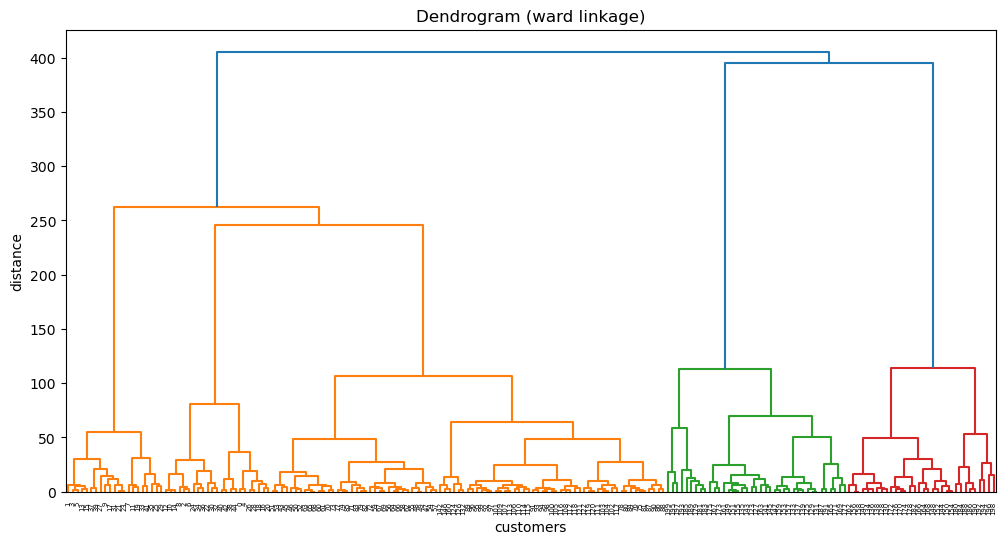

In [4]:
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Dendrogram (ward linkage)")
plt.xlabel("customers")
plt.ylabel("distance")
plt.show()

## How to read this thing

At the very bottom every customer is its own leaf. As you go up, branches join together, and the height of a join is the distance at which those two clusters merged.

A big tall jump (a long vertical line where nothing joins for a while) means those two groups are far apart, so its a natural place to seperate clusters. To pick the number of clusters you just imagine a horizontal line cutting across the tree and count how many vertical lines it crosses. Cut low and you get many clusters, cut high and you get few.

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Cutting the tree</b>
</h2>
<div style="font-family:'Times New Roman';">
There is a big gap in the tree, so if i draw a cut through that gap it gives 5 clusters for this data. Let me draw the cut line and then actually cut it.
</div>

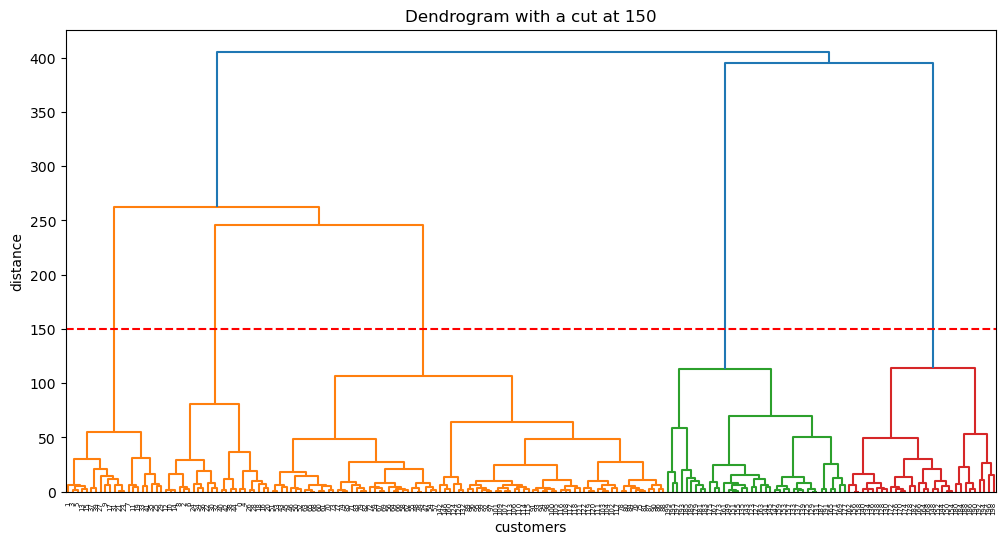

In [6]:
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.axhline(y=150, color='red', linestyle='--')   # this is where i cut
plt.title("Dendrogram with a cut at 150")
plt.xlabel("customers")
plt.ylabel("distance")
plt.show()

clusters: 5


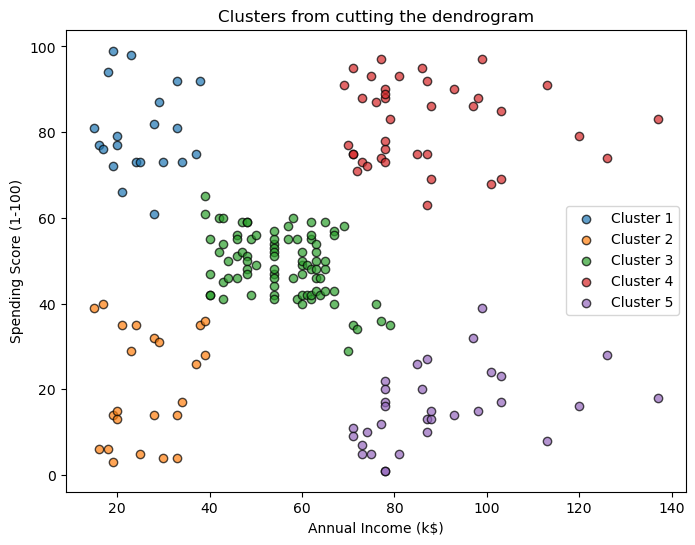

In [7]:
labels = fcluster(Z, t=5, criterion='maxclust')
print("clusters:", len(set(labels)))

plt.figure(figsize=(8, 6))
for c in set(labels):
    plt.scatter(X[labels == c, 0], X[labels == c, 1], edgecolors='k', alpha=0.7, label=f"Cluster {c}")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Clusters from cutting the dendrogram")
plt.legend()
plt.show()

### what i learned here

- a dendrogram shows the full merge history, and the height of a join is the merge distance
- tall jumps in the tree are good places to cut
- cutting at 5 gives basically the same kind of customer segments as the sklearn notebook, but now i actually have a reason for picking 5 instead of just guessing
- fcluster is the function that gives you the labels once you decide where to cut

and thats hierarchical clustering, from the idea, to running it, to reading the dendrogram.